In [1]:
# Get parent directory and add to sys.path
import os; import sys
import numpy as np
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
# MPC import
from Deliverable_5_2.LinearMPC_bigger_param.MPCVelControl import MPCVelControl

from src.rocket import Rocket
from src.vel_rocket_vis import RocketVis, plot_static_states_inputs

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

In [ ]:
Ts = 0.05
sim_time = 21.2; H = 10.0
x0 = np.array([0, 0, 0, 0, 0, 0, 5, 5, 10, 0, 0, 1])  # initial state
x_target = np.zeros((12,))

rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
mpc = MPCVelControl().new_controller(rocket, Ts, H)

# Static mass change and zero fuel rate
rocket.mass = 2.0
rocket.fuel_rate = 0.1
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, ref = rocket.simulate_control(mpc, sim_time, H, x0, x_target=x_target, method='nonlinear')

vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:,:-1], u_cl, Ref=ref[:,:-1], T_ol=t_ol[...,:-1], X_ol=x_ol, U_ol=u_ol); 


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Simulating time 0.00: Fuel left: 1.00 kg, m=2.00, Pavg=40.0, Fz=11.28, mg=19.61, az=-4.16, Fuel left: 1.00 kg, 
Simulating time 0.05: Fuel left: 1.00 kg, m=2.00, Pavg=40.0, Fz=11.72, mg=19.59, az=-3.94, Fuel left: 1.00 kg, 
Simulating time 0.10: Fuel left: 1.00 kg, m=2.00, Pavg=40.0, Fz=11.76, mg=19.57, az=-3.91, Fuel left: 0.99 kg, 
Simulating time 0.15: Fuel left: 0.99 kg, m=1.99, Pavg=40.0, Fz=11.69, mg=19.55, az=-3.94, Fuel left: 0.99 kg, 
Simulating time 0.20: Fuel left: 0.99 kg, m=1.99, Pavg=40.0, Fz=11.61, mg=19.53, az=-3.98, Fuel left: 0.99 kg, 
Simulating time 0.25: Fuel left: 0.99 kg, m=1.99, Pav

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=422, step=2), IntSlider(value=0…

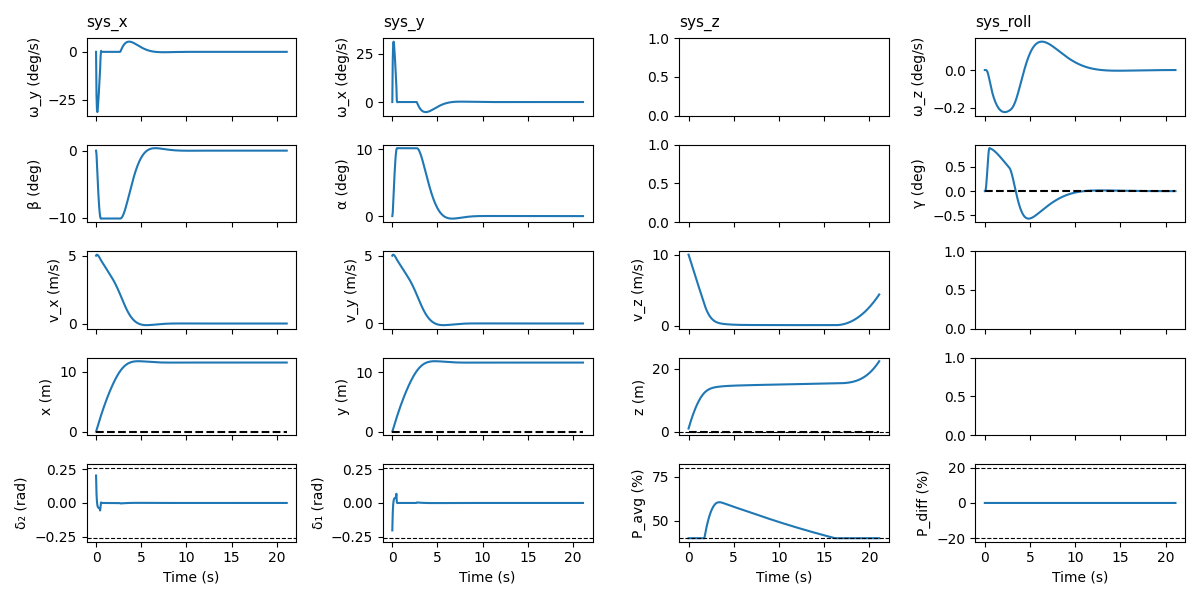

In [4]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl, ref[:,:-1])

(423,)


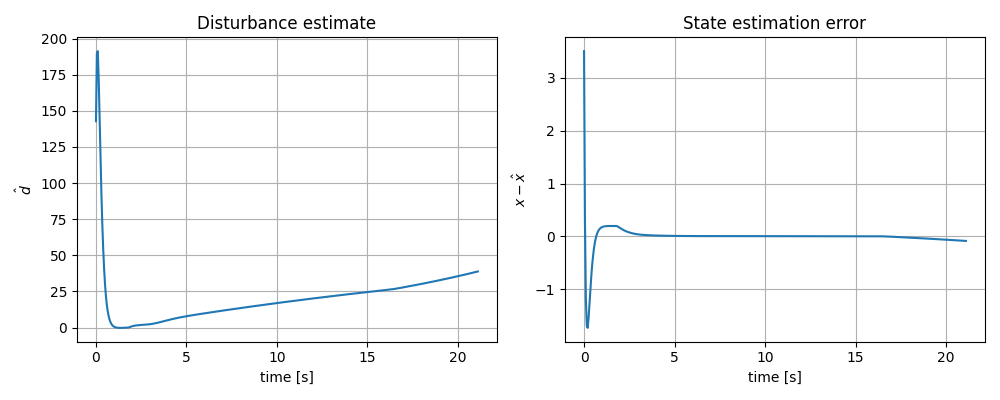

In [5]:
import matplotlib.pyplot  as plt
d_hat = np.array(mpc.mpc_z.d_hat_hist).squeeze()
print(d_hat.shape)
x_err = np.array(mpc.mpc_z.x_err_hist).squeeze()

Ts = 0.05
t = np.arange(len(d_hat)) * Ts

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(t, d_hat)
plt.xlabel("time [s]")
plt.ylabel(r"$\hat d$")
plt.title("Disturbance estimate")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(t, x_err)
plt.xlabel("time [s]")
plt.ylabel(r"$x - \hat x$")
plt.title("State estimation error")
plt.grid(True)

plt.tight_layout()
plt.show()


(423,)
0.007354499999999999


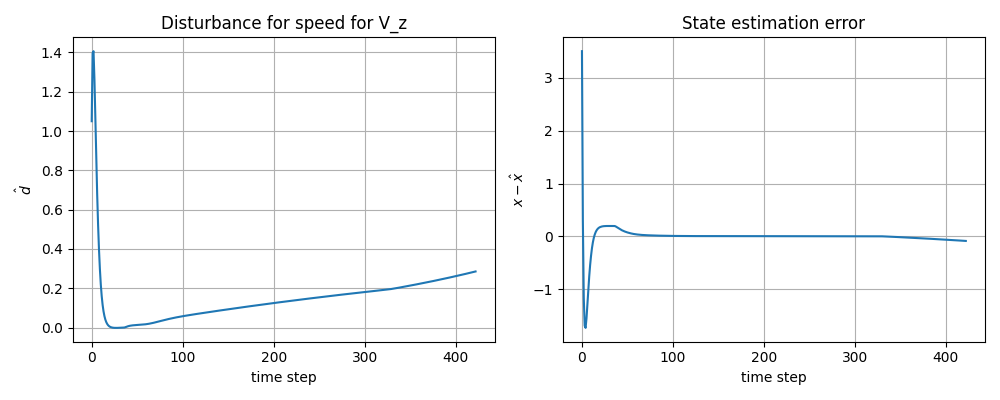

In [6]:
print(d_hat.shape)
print(mpc.mpc_z.Bd[0,0])

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(mpc.mpc_z.Bd[0,0] * d_hat)
plt.xlabel("time step")
plt.ylabel(r"$\hat d$")
plt.title("Disturbance for speed for V_z")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(x_err)
plt.xlabel("time step")
plt.ylabel(r"$x - \hat x$")
plt.title("State estimation error")
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
d_hat[-1]* mpc.mpc_z.Bd[0,0]


np.float64(0.2854540696086534)

In [8]:
print(x_err[-1])

-0.08439456462886596


In [9]:
IAE = np.sum(np.abs(x_err))
print("IAE =", IAE)

IAE = 26.21064500939365
